# 10 — Charting agent and the sandbox

Modules 08 and 09 answered Helena from Chinook with named tools. A BI question is the same shop and a new kind of hand: **the model writes Python, and that Python has to run somewhere**.

This is the only module where we execute model-written code. Module 04's coding agent wrote files. `run_tests` was a fixed command. Today the payload *is* the program.

The model still does not call `matplotlib`. It emits a string. Your code decides whether that string becomes a process.

```
08/09   named query  ->  a number or a name
10      named query  ->  a table
        model writes matplotlib
        YOUR runner starts a process  ->  a PNG
```


## 1. Learn

```
04  five file tools, no run_bash
08  Chinook through the SDK
09  the same desk as a graph
10  you are here — the model writes code; you choose the process
11  retrieval over data/corpus/ (already on disk; not today)
```

Four controls, and they are separate. A timeout is not a filesystem. `cwd=` is not a chroot.

| Control | What it stops | What it does not stop |
|---|---|---|
| **Timeout** | `while True` | Reading `.env` |
| **Working directory** | Accidental relative writes | `Path("../../../.env")` |
| **Network egress** | Calling out | Reading the disk the process can see |
| **Filesystem scope** | Seeing the host at all | Nothing, if you skipped it |

```mermaid
flowchart LR
    subgraph U["unconstrained exec"]
        U1["this kernel<br/>sees .env, chinook.db,<br/>the whole VM"]
    end
    subgraph J["subprocess, cwd=charts/"]
        J1["child process<br/>timeout, cwd set<br/>STILL sees ../../../.env"]
    end
    subgraph D["Docker"]
        D1["container<br/>--network none<br/>only charts/ is mounted"]
    end
```
Bare `exec` in this kernel, or `subprocess` with only a timeout, is the first column of a threat model, not a sandbox. Docker (no network, one mounted folder) is the first boundary that actually removes the rest of the disk. Hosted sandboxes (E2B, Azure Container Apps, and the rest) are that idea as a service. One sentence: we are not signing up for those today.

The official loop from 03 runs two tools: one query, one `run_python`. We will watch the generated code before we decide to run it. Then we will run a planted snippet that walks up to `.env` — first in the jail, then in Docker if the daemon is up.

Cut first if the VM has no Docker: keep the jail and the planted snippet. The container cell prints the command and stops.


## 2. Do

### Load the environment and Chinook


In [1]:
from pathlib import Path
import json
import os
import sqlite3
import subprocess
import sys

from dotenv import load_dotenv, find_dotenv
from IPython.display import Image, display
from openai import OpenAI


load_dotenv(find_dotenv(usecwd=True))
ROOT = Path(find_dotenv(usecwd=True)).parent

api_key = os.environ.get("OPENAI_API_KEY", "").strip()
model = (
    os.environ.get("MODEL_STRONG", "").strip()
    or os.environ.get("MODEL_DEFAULT", "").strip()
)
assert api_key, "OPENAI_API_KEY is missing."
assert model, "Set MODEL_STRONG or MODEL_DEFAULT in .env."

client = OpenAI()
HERE = ROOT / "modules" / "10_charting_sandbox"
CHARTS = HERE / "charts"
CHARTS.mkdir(exist_ok=True)
sys.path.insert(0, str(HERE))

# Frameworks are not in this module, but later reuse should keep this flag.
db = sqlite3.connect(ROOT / "data" / "chinook.db", check_same_thread=False)
db.row_factory = sqlite3.Row

print("OPENAI_API_KEY is set:", True)
print("model for this module:", model)
print("charts:", CHARTS)
print("invoices:", db.execute("select count(*) from invoices").fetchone()[0])


OPENAI_API_KEY is set: True
model for this module: gpt-5.4-mini
charts: /Users/tarekatwan/Downloads/ai_agents_course/modules/10_charting_sandbox/charts
invoices: 412


### Named queries, not free SQL

Same rule as 08. A guessed `SELECT` is someone else's invoices. Two aggregates, printed with no model.


In [2]:
def invoices_by_country() -> str:
    rows = db.execute(
        """
        select c.Country as country,
               count(i.InvoiceId) as n,
               round(sum(i.Total), 2) as spend
        from invoices i
        join customers c on c.CustomerId = i.CustomerId
        group by c.Country
        order by spend desc
        """
    ).fetchall()
    lines = ["country | invoices | spend"]
    for row in rows:
        lines.append(f"{row['country']} | {row['n']} | {row['spend']}")
    return "\n".join(lines)


def invoices_by_year() -> str:
    rows = db.execute(
        """
        select substr(InvoiceDate, 1, 4) as year,
               count(*) as n,
               round(sum(Total), 2) as spend
        from invoices
        group by year
        order by year
        """
    ).fetchall()
    lines = ["year | invoices | spend"]
    for row in rows:
        lines.append(f"{row['year']} | {row['n']} | {row['spend']}")
    return "\n".join(lines)


print(invoices_by_country())
print()
print(invoices_by_year())


country | invoices | spend
USA | 91 | 523.06
Canada | 56 | 303.96
France | 35 | 195.1
Brazil | 35 | 190.1
Germany | 28 | 156.48
United Kingdom | 21 | 112.86
Czech Republic | 14 | 90.24
Portugal | 14 | 77.24
India | 13 | 75.26
Chile | 7 | 46.62
Ireland | 7 | 45.62
Hungary | 7 | 45.62
Austria | 7 | 42.62
Finland | 7 | 41.62
Netherlands | 7 | 40.62
Norway | 7 | 39.62
Sweden | 7 | 38.62
Spain | 7 | 37.62
Poland | 7 | 37.62
Italy | 7 | 37.62
Denmark | 7 | 37.62
Belgium | 7 | 37.62
Australia | 7 | 37.62
Argentina | 7 | 37.62

year | invoices | spend
2009 | 83 | 449.46
2010 | 83 | 481.45
2011 | 83 | 469.58
2012 | 83 | 477.53
2013 | 80 | 450.58


Those numbers are the ground truth. USA is **523.06** across 91 invoices. The years 2009–2012 each have **83** invoices; 2013 has **80**. Cover the print. The model has not seen this yet.

### You plot first

No model. `matplotlib` is already in the course venv. Save under `charts/`. Then we will ask the model to write the same kind of file.


/Users/tarekatwan/Downloads/ai_agents_course/modules/10_charting_sandbox/charts/country_revenue_hand.png
bytes: 18898


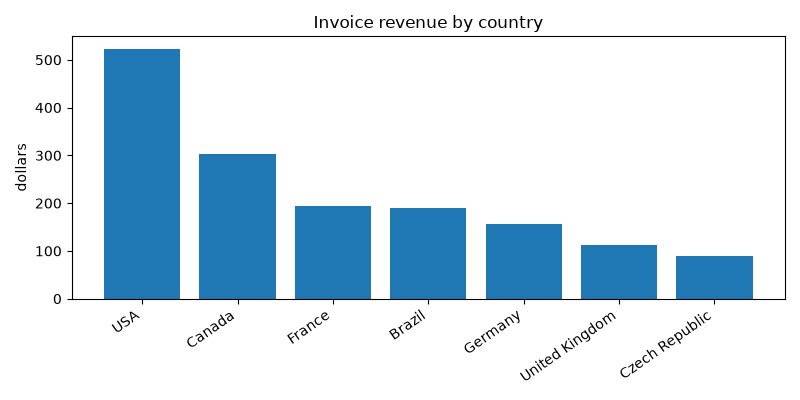

In [3]:
import matplotlib.pyplot as plt

rows = [line.split(" | ") for line in invoices_by_country().splitlines()[1:8]]
labels = [r[0] for r in rows]
values = [float(r[2]) for r in rows]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.title("Invoice revenue by country")
plt.ylabel("dollars")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
hand_path = CHARTS / "country_revenue_hand.png"
plt.savefig(hand_path)
plt.close()
print(hand_path)
print("bytes:", hand_path.stat().st_size)
display(Image(filename=str(hand_path)))


### The runner, built here first

`run_python` will be a tool. Before any model, we write the process it starts.

Timeout 15 seconds. `cwd` is `charts/`. The child does not inherit `OPENAI_API_KEY`. It still has `sys.executable`, so it can import `matplotlib` from this venv.

That is two of the four controls. It is **not** a filesystem sandbox. The next cell proves it.


In [4]:
def run_jailed(code: str, timeout: int = 15) -> str:
    mpl = CHARTS / ".mpl"
    mpl.mkdir(exist_ok=True)
    script = CHARTS / "_run.py"
    script.write_text(code)
    env = {
        "PATH": os.environ.get("PATH", ""),
        "MPLCONFIGDIR": str(mpl),
        "HOME": str(CHARTS),
    }
    try:
        proc = subprocess.run(
            [sys.executable, str(script)],
            cwd=str(CHARTS),
            env=env,
            capture_output=True,
            text=True,
            timeout=timeout,
        )
    except subprocess.TimeoutExpired:
        return "timed out"
    out = (proc.stdout or "") + (proc.stderr or "")
    if proc.returncode != 0:
        return "error: " + out[-800:]
    return out[-800:] if out.strip() else "ok"


print(run_jailed("print(2 + 2)"))


4



Same function, extracted, lives in `sandbox.py` next to this notebook. A `.py` file is allowed because Docker has to start a process. Open it after this cell. Do not run it yet.

### The planted snippet

From `charts/`, the repo `.env` is `../../../.env`. We print **whether the file exists**. We do not print the file.


In [5]:
PROBE = """
from pathlib import Path
p = Path("../../../.env")
print("cwd", Path.cwd())
print("env_exists", p.exists())
"""

print("--- unconstrained (this kernel) ---")
p = Path("../../../.env")
# When Jupyter started at the repo root this is the wrong relative path.
# Use ROOT so the demo does not depend on cwd.
print("env_exists", (ROOT / ".env").exists())

print("--- jailed subprocess ---")
print(run_jailed(PROBE))


--- unconstrained (this kernel) ---
env_exists True
--- jailed subprocess ---
cwd /Users/tarekatwan/Downloads/ai_agents_course/modules/10_charting_sandbox/charts
env_exists True



The jail printed `env_exists True` (or it will, when `charts/` is three levels below the repo). Timeout and `cwd` did not hide the file. The child walked up.

`sandbox.py` has `run_docker`: `--network none`, only `charts/` mounted at `/work`, image `python:3.12-slim`. **Pre-pulled into the VM.** We do not `docker pull` in this room.

If the daemon is down or the image is missing, the cell says so and we move on. Do not start a pull.


In [6]:
from sandbox import run_docker

print(run_docker(PROBE))


docker image missing: python:3.12-slim (pre-pull into the VM; do not pull in class)


If that printed `env_exists False`, the container could not see the host `.env`. Same snippet. Different disk. That is filesystem scope.

If it printed `docker image missing` or could not talk to the daemon, you still have the lesson from the jail cell. The command the VM image should already have run:

```
docker pull python:3.12-slim
```

### Tools, then one create, then look

Two tools. `run_python` is `run_jailed`. The child has no database. The model has to put the numbers from the query into the plot code.


In [7]:
def schema(tool_name, description, **props):
    return {"type": "function", "function": {
        "name": tool_name, "description": description,
        "parameters": {"type": "object", "properties": props, "required": list(props)}}}


def run_python(code: str) -> str:
    return run_jailed(code)


tools = [
    schema(
        "invoices_by_country",
        "Invoice count and spend in dollars, one row per country, spend descending.",
    ),
    schema(
        "invoices_by_year",
        "Invoice count and spend in dollars, one row per year.",
    ),
    schema(
        "run_python",
        "Run matplotlib code in a child process whose cwd is the charts folder. "
        "Save a PNG in that folder. Put the numbers in the code; there is no database in that process.",
        code={"type": "string"},
    ),
]


def run_call(call):
    name = call.function.name
    args = json.loads(call.function.arguments or "{}")
    if name == "invoices_by_country":
        return invoices_by_country()
    if name == "invoices_by_year":
        return invoices_by_year()
    if name == "run_python":
        return run_python(args.get("code", ""))
    return "unknown tool"


print([t["function"]["name"] for t in tools])


['invoices_by_country', 'invoices_by_year', 'run_python']


One `create`. Stop. If it asked for `run_python`, read the `code` argument before anyone runs it. That is the module 02 pause, applied to a program.


In [8]:
QUESTION = (
    "Make a bar chart of invoice revenue by country. "
    "Use the top 8 countries. Save it as country_revenue.png."
)

messages = [
    {
        "role": "system",
        "content": (
            "You answer with tools. Query first. Then call run_python with matplotlib code "
            "that saves the PNG. Do not invent numbers."
        ),
    },
    {"role": "user", "content": QUESTION},
]

response = client.chat.completions.create(
    model=model,
    messages=messages,
    tools=tools,
    max_completion_tokens=400,
    reasoning_effort="none",
)
message = response.choices[0].message
print("finish_reason:", response.choices[0].finish_reason)
print("n tool_calls: ", len(message.tool_calls or []))
if message.tool_calls:
    for call in message.tool_calls:
        print(" asked:", call.function.name)
        print(call.function.arguments[:500])


finish_reason: tool_calls
n tool_calls:  1
 asked: invoices_by_country
{}


### The official loop

Cap of 6. Print each tool name. When `run_python` runs, print the first lines of the code it sent. The PNG path we care about is `charts/country_revenue.png`.


--- turn 1 finish_reason: tool_calls ---
invoices_by_country -> country | invoices | spend | USA | 91 | 523.06 | Canada | 56 | 303.96 | France | 35 | 195.1 | Brazil | 35 | 190.1 | Germany | 28 | 156.48 | United Kingdom | 21 | 112.86 | Cze


--- turn 2 finish_reason: tool_calls ---
run_python, first lines:
import matplotlib.pyplot as plt

countries = ['USA', 'Canada', 'France', 'Brazil', 'Germany', 'United Kingdom', 'Czech Republic', 'Portugal']
revenue = [523.06, 303.96, 195.10, 190.10, 156.48, 112.86, 90.24, 77.24]

plt.figure(figsize=(10, 6))
bars = plt.bar(countries, revenue, color='steelblue')
plt.title('Invoice Revenue by Country (Top 8)')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()


run_python -> Matplotlib is building the font cache; this may take a moment. | 


--- turn 3 finish_reason: stop ---
Done — I created the bar chart for the top 8 countries and saved it as **country_revenue.png**.

chart exists: True
bytes: 56460


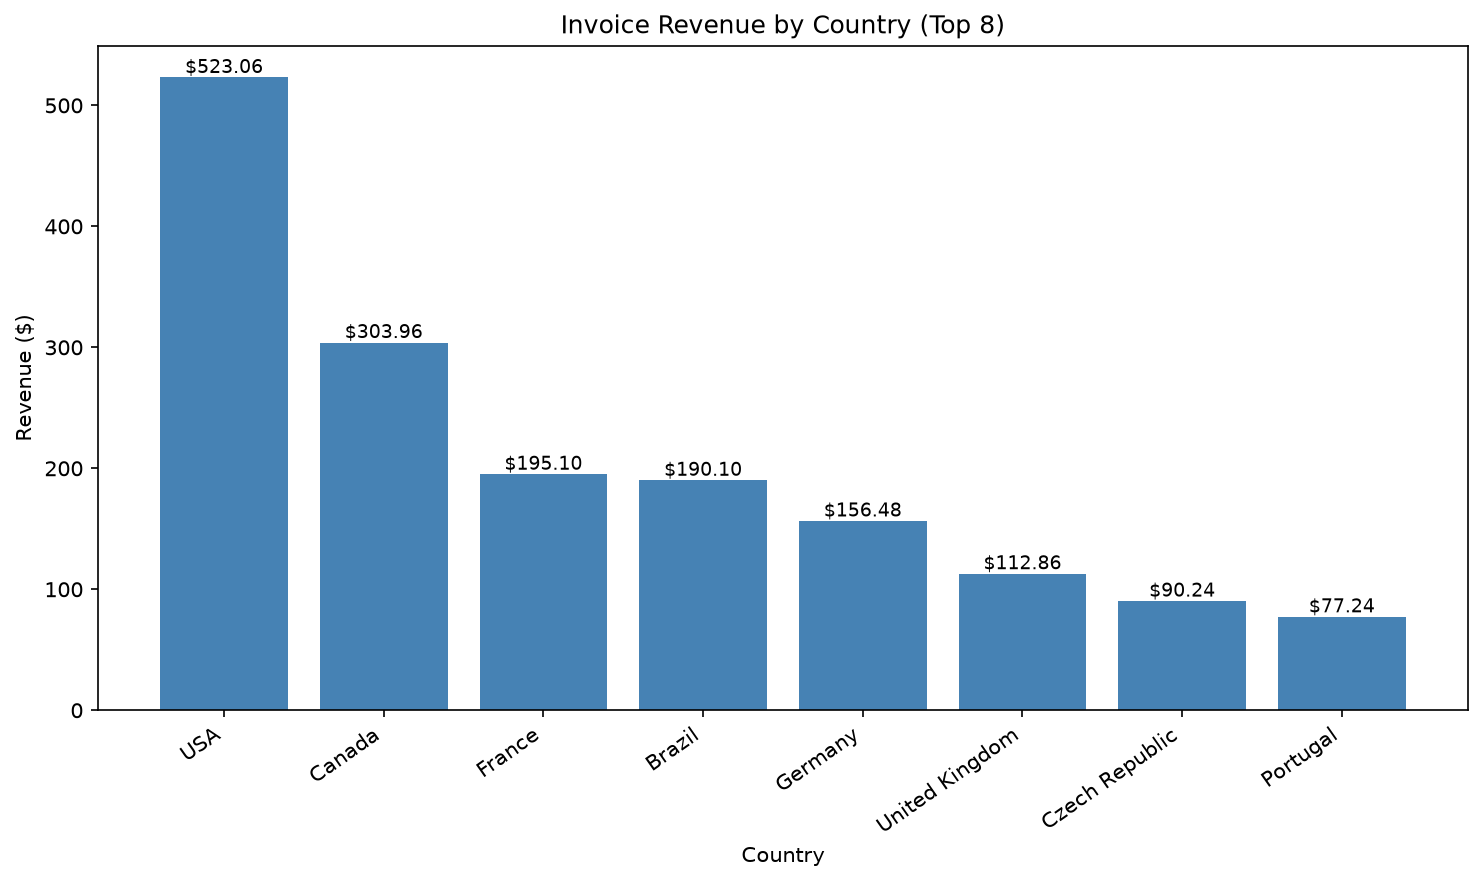

In [9]:
messages = [
    {
        "role": "system",
        "content": (
            "You answer with tools. Query first. Then call run_python with matplotlib code "
            "that saves the PNG. Do not invent numbers."
        ),
    },
    {"role": "user", "content": QUESTION},
]
generated_code = None
for turn in range(6):
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        tools=tools,
        max_completion_tokens=500,
        reasoning_effort="none",
    )
    message = response.choices[0].message
    print("--- turn", turn + 1, "finish_reason:", response.choices[0].finish_reason, "---")
    if not message.tool_calls:
        print(message.content)
        break
    messages.append(message)
    for call in message.tool_calls:
        args = json.loads(call.function.arguments or "{}")
        if call.function.name == "run_python":
            generated_code = args.get("code", "")
            print("run_python, first lines:")
            print("\n".join(generated_code.splitlines()[:12]))
        result = run_call(call)
        print(call.function.name, "->", str(result)[:160].replace("\n", " | "))
        messages.append({"role": "tool", "tool_call_id": call.id, "content": result})

chart_path = CHARTS / "country_revenue.png"
print()
print("chart exists:", chart_path.exists())
if chart_path.exists():
    print("bytes:", chart_path.stat().st_size)
    display(Image(filename=str(chart_path)))


## 3. Observe

The string the model sent is the payload. The jail is the decision. The PNG is only evidence that we said yes.


In [10]:
print("generated_code is None:", generated_code is None)
if generated_code:
    print("characters:", len(generated_code))
    print("mentions savefig:", "savefig" in generated_code)
    print("mentions sqlite:", "sqlite" in generated_code.lower())

print()
print("hand plot bytes:  ", (CHARTS / "country_revenue_hand.png").stat().st_size)
agent_png = CHARTS / "country_revenue.png"
print("agent plot exists:", agent_png.exists())
if agent_png.exists():
    print("agent plot bytes: ", agent_png.stat().st_size)

print()
print("jail env_exists (from earlier probe) used Path('../../../.env')")
print("docker is the first control that can make that False")


generated_code is None: False
characters: 673
mentions savefig: True
mentions sqlite: False

hand plot bytes:   18898
agent plot exists: True
agent plot bytes:  56460

jail env_exists (from earlier probe) used Path('../../../.env')
docker is the first control that can make that False


Things to notice:

- `arguments` for `run_python` is still a JSON **string**. Same as module 02.
- The child has no `chinook.db`. If the bars look right, the numbers came from the query observation, not from a second SQL.
- `cwd=charts/` did not hide `.env`. Do not ship that runner as "sandboxed."
- Docker, when the image is local, is one volume and no network. Pull it before class.

## 4. Challenge

Official loop. A new chart, same two query tools and `run_python`:

> Make a bar chart of invoice **count** by year. Save it as `invoices_by_year.png`.

Bind `chart_path` to that file (a `Path` or a string). The next cell checks that the file exists and is not empty. It does not score the wording.


In [ ]:
# chart_path = ...


In [ ]:
from pathlib import Path as _Path

p = _Path(chart_path)
assert p.is_file(), "chart_path should be invoices_by_year.png under charts/"
assert p.stat().st_size > 500, "the PNG should not be an empty file"
print("looks good")
